In [1]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, BisectingKMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import scipy
from kneed import KneeLocator
from typing import Tuple, Literal, Any, Optional
import scipy.stats as stats
from gensim.models import KeyedVectors
import re
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib as mpl
from cycler import cycler
from utils import *
from utils import find_elbow, _remap


In [2]:
print(sanity_check())

Version 2


In [3]:
mpl.rcParams['axes.prop_cycle'] = cycler(color=['teal', 'maroon', 'steelblue', '#3EB489', '#6B8E23'])

In [4]:
df = pd.read_csv('/home/uplong/Downloads/DSU-Dataset.csv', parse_dates=['Date'], dtype={'Hour':'int32'})
display(df)

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted
0,A,2018-01-01,0,BREATHING PROBLEM,1,1
1,A,2018-01-01,0,BURN,1,0
2,A,2018-01-01,0,SHAKING,1,1
3,A,2018-01-01,0,VOMITING,1,0
4,A,2018-01-01,1,FROSTBITE,1,0
...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0
1174306,D,2025-08-31,23,CHEST PAIN,1,0
1174307,D,2025-08-31,23,DIZZINESS,1,0
1174308,D,2025-08-31,23,FINGER PAIN,1,0


In [5]:
display(df.isna().sum())

Site                    0
Date                    0
Hour                    0
REASON_VISIT_NAME    6205
ED Enc                  0
ED Enc Admitted         0
dtype: int64

In [6]:
df.describe()

,Date,Hour,ED Enc,ED Enc Admitted
count,1174310,1.174310e+06,1.174310e+06,1.174310e+06
mean,2021-12-05 23:13:59.314321664,1.354932e+01,1.084646e+00,2.915218e-01
min,2018-01-01 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00
25%,2019-12-23 00:00:00,1.000000e+01,1.000000e+00,0.000000e+00
50%,2021-12-30 00:00:00,1.400000e+01,1.000000e+00,0.000000e+00
75%,2023-11-11 00:00:00,1.900000e+01,1.000000e+00,1.000000e+00
max,2025-08-31 00:00:00,2.300000e+01,8.000000e+00,5.000000e+00
std,NaN,6.142173e+00,3.228135e-01,4.772703e-01


In [7]:
df['ED Enc Admitted'].sum() / df['ED Enc'].sum() # overall admission rate

np.float64(0.26877133038813356)

In [8]:
df.REASON_VISIT_NAME.fillna('NaN', inplace=True)

/tmp/ipykernel_40679/2663292634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.REASON_VISIT_NAME.fillna('NaN', inplace=True)


## Reason of encounter analysis

In [9]:
unique_reasons = df['REASON_VISIT_NAME'].unique()
unique_reasons.sort()

In [10]:
reason_count = (
    df.groupby('REASON_VISIT_NAME')
      .agg(
          total_occurences_of_reason=('REASON_VISIT_NAME', 'size'),
          total_visits=('ED Enc', 'sum'),
          total_admitted=('ED Enc Admitted', 'sum')
      )
      .sort_values(by='total_visits', ascending=False)
)
reason_count['percentage_of_admission'] = (reason_count['total_admitted'] / reason_count['total_visits'])*100
display(reason_count)
reason_count.describe()

,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admission
REASON_VISIT_NAME,,,,
ABDOMINAL PAIN,94739,123575,36534,29.564232
CHEST PAIN,68213,82502,31341,37.988170
FALL,46042,52970,19569,36.943553
SHORTNESS OF BREATH,42243,48018,27345,56.947395
BACK PAIN,32299,35338,5849,16.551588
...,...,...,...,...
ADENOPATHY,1,1,1,100.000000
UPPER GI PROCEDURE,1,1,1,100.000000
ACCESSORY NIPPLE,1,1,0,0.000000


,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admission
count,868.000000,868.000000,868.000000,868.000000
mean,1352.891705,1467.408986,394.397465,26.166079
std,5481.191807,6532.125310,2215.047504,28.091508
min,1.000000,1.000000,0.000000,0.000000
25%,5.000000,5.000000,1.000000,2.976139
50%,38.500000,39.000000,7.000000,16.609127
75%,503.000000,504.500000,91.000000,42.145464
max,94739.000000,123575.000000,36534.000000,100.000000


<Axes: xlabel='REASON_VISIT_NAME'>

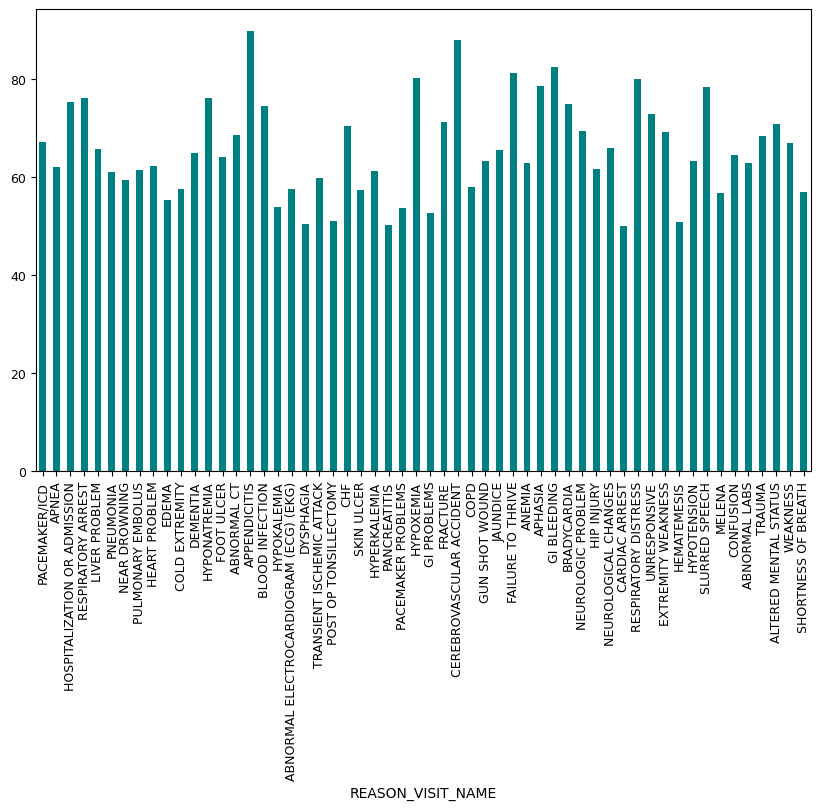

In [11]:
importance_df = reason_count[(reason_count['percentage_of_admission']>50) & (reason_count['total_visits']>50)].sort_values(by='total_occurences_of_reason', ascending=True)
importance_df['percentage_of_admission'].plot(kind='bar', figsize=(10,6), fontsize=9)

## Date/Time analysis

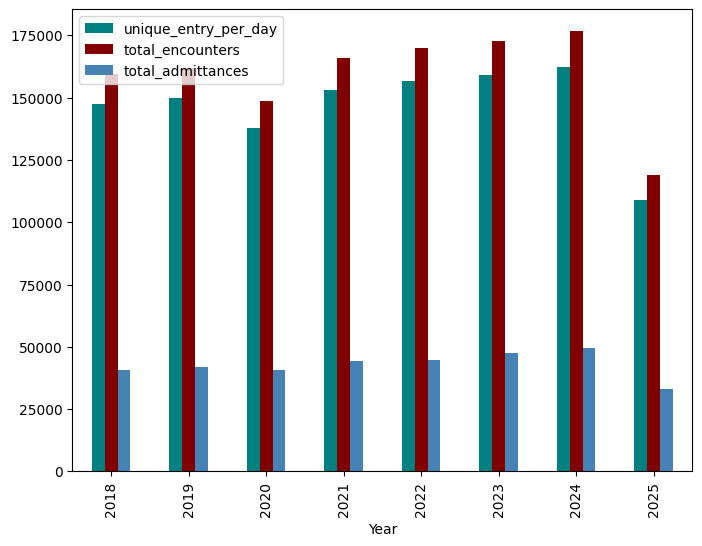

In [12]:
grouped_by_year = df.groupby(by = df['Date'].dt.year).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_year.plot(kind='bar', figsize=(8,6), xlabel='Year')
plt.show()

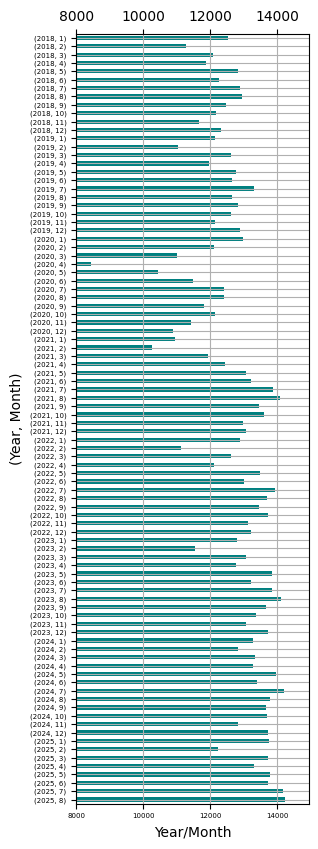

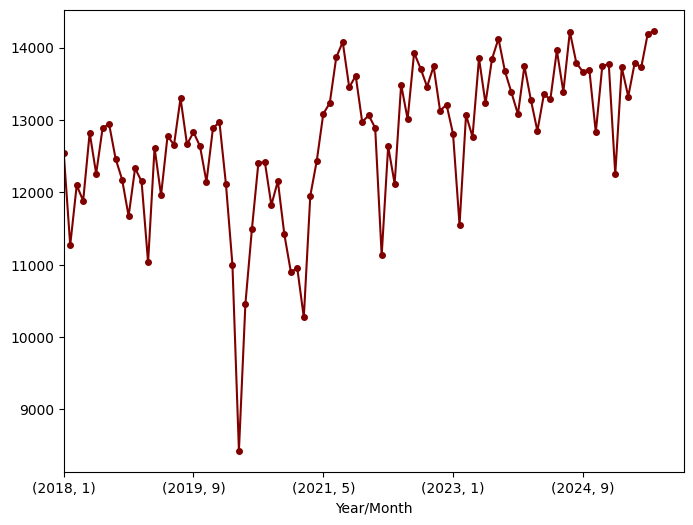

In [13]:
grouped_by_year_month = df.groupby(by = [df['Date'].dt.year, df['Date'].dt.month]).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
# for i in range(2018,2026):
#     grouped_by_year.loc[i].plot.bar()

ax1 = grouped_by_year_month['unique_entry_per_day'].plot(kind='barh', figsize = (3,10), xlabel='Year/Month', xlim=8000, grid=True, fontsize=5)
ax1.invert_yaxis()
ax1.tick_params(top=True, labeltop=True)
ax1.set_ylabel('(Year, Month)')
plt.show()
ax2 = grouped_by_year_month['unique_entry_per_day'].plot(kind='line', figsize = (8,6), xlabel='Year/Month', xlim=0, color='maroon', marker='o', markersize=4)
plt.show()



,unique_entry_per_day,total_encounters,total_admissions,admission_ratio
Date,,,,
1,87596,95389,25518,0.267515
2,80217,87108,23276,0.267209
3,86727,94102,25320,0.269070
4,82892,89607,24630,0.274867
5,90455,97616,26399,0.270437
6,89273,96345,26025,0.270123
7,94468,101979,26880,0.263584
8,93729,101648,26929,0.264924
9,91378,98973,26058,0.263284


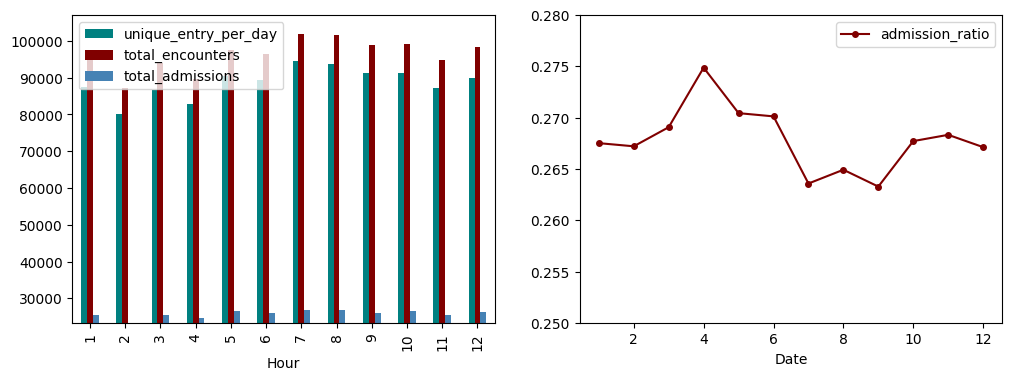

In [14]:
grouped_by_month = df[df['Date'].dt.year < 2025].groupby(by = df['Date'].dt.month).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admissions = ('ED Enc Admitted', 'sum')
    )
grouped_by_month['admission_ratio'] = (grouped_by_month['total_admissions'] / grouped_by_month['total_encounters'])
display(grouped_by_month)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))  
grouped_by_month.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_month.iloc[:,:-1].min()['total_admissions'], ax=axes[0])
grouped_by_month['admission_ratio'].plot(kind='line', ylim=(0.25, 0.28), ax=axes[1], color='maroon', legend=True, marker='o', markersize=4)
plt.show()

,unique_entry_per_day,total_encounters,total_admissions,admission_ratio
Date,,,,
1,38527,41836,11127,0.265967
2,38640,42038,11151,0.265260
3,39098,42388,11273,0.265948
4,38574,41786,11116,0.266022
5,38910,42244,11342,0.268488


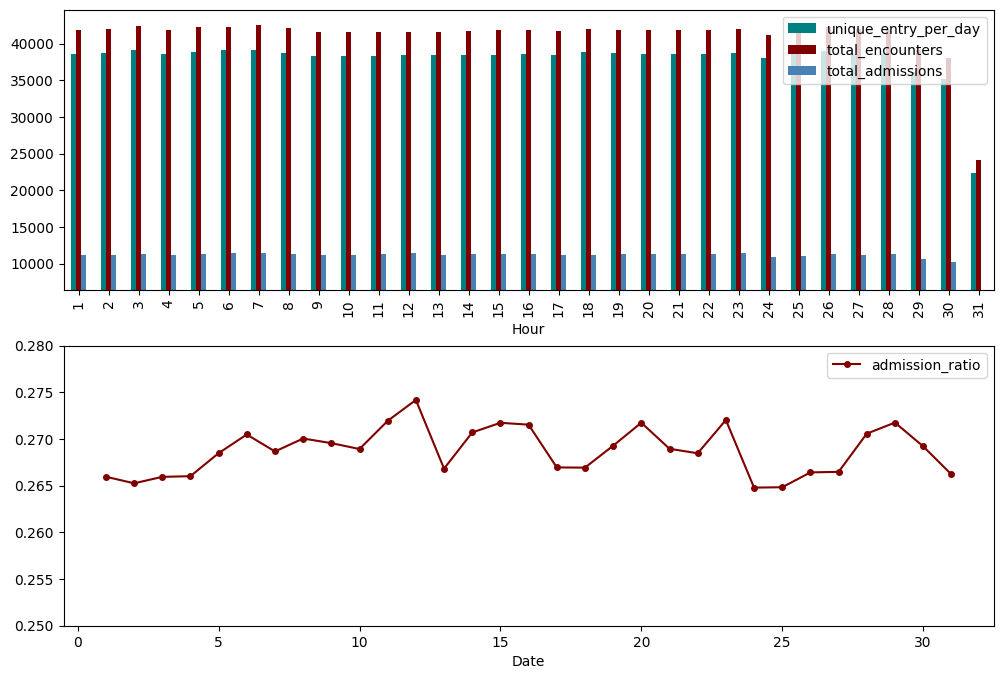

In [15]:
grouped_by_day = df.groupby(by = df['Date'].dt.day).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admissions = ('ED Enc Admitted', 'sum')
    )
grouped_by_day['admission_ratio'] = (grouped_by_day['total_admissions'] / grouped_by_day['total_encounters'])
display(grouped_by_day.head(5))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))  
grouped_by_day.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_day.iloc[:,:-1].min()['total_admissions'], ax=axes[0])
grouped_by_day['admission_ratio'].plot(kind='line', ylim=(0.25, 0.28), ax=axes[1], color='maroon', legend=True, marker='o', markersize=4)
plt.show()

# grouped_by_day.plot(kind='bar', figsize = (15,6), xlabel='Day of the month')

,unique_entry_per_day,total_encounters,total_admissions,admission_ratio
Date,,,,
0,176124,192519,52940,0.274986
1,166491,181060,49882,0.275500
2,165012,179035,49507,0.276521
3,162961,176553,49012,0.277605
4,165587,179223,49973,0.278831
5,167234,180421,44874,0.248718
6,170901,184900,46149,0.249589


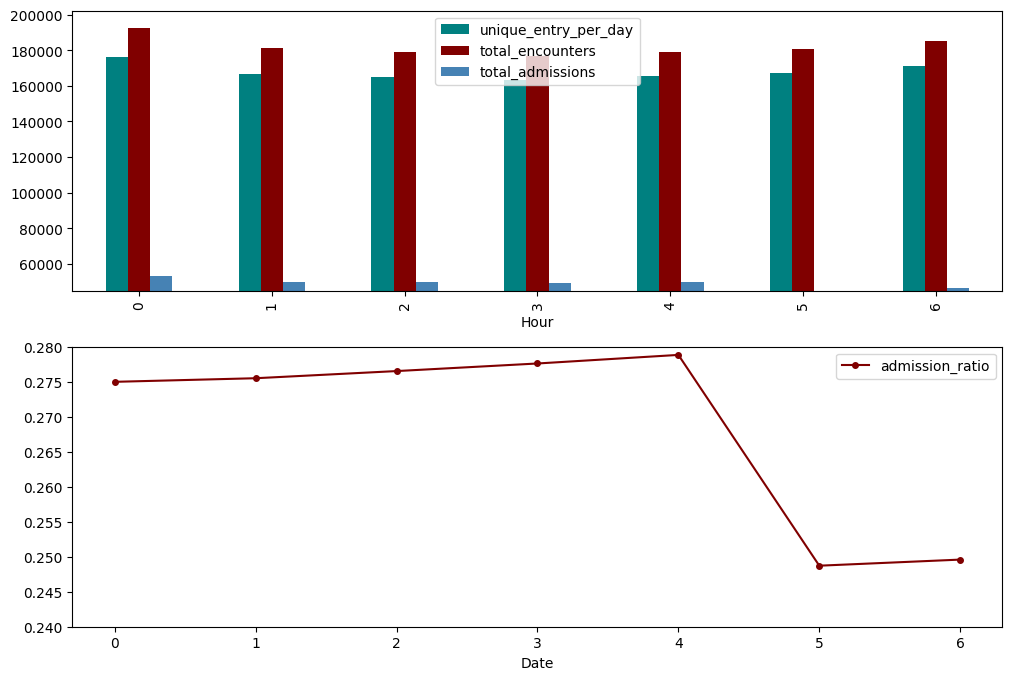

In [16]:
grouped_by_day_of_week = df.groupby(by = df['Date'].dt.day_of_week).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admissions = ('ED Enc Admitted', 'sum')
    )

grouped_by_day_of_week['admission_ratio'] = (grouped_by_day_of_week['total_admissions'] / grouped_by_day_of_week['total_encounters'])
display(grouped_by_day_of_week)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))  
grouped_by_day_of_week.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_day_of_week.iloc[:,:-1].min()['total_admissions'], ax=axes[0])
grouped_by_day_of_week['admission_ratio'].plot(kind='line', ylim=(0.24, 0.28), ax=axes[1], color='maroon', legend=True, marker='o', markersize=4)
plt.show()

In [17]:
# grouped_by_year_reasons = df.groupby(by = [df['Date'].dt.year, df['REASON_VISIT_NAME']]).agg('size')
# grouped_by_year_reasons = grouped_by_year_reasons.reset_index()
# display(grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500)],
#         grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500) & (grouped_by_year_reasons['REASON_VISIT_NAME']=='ALLERGIC REACTION')]
# )

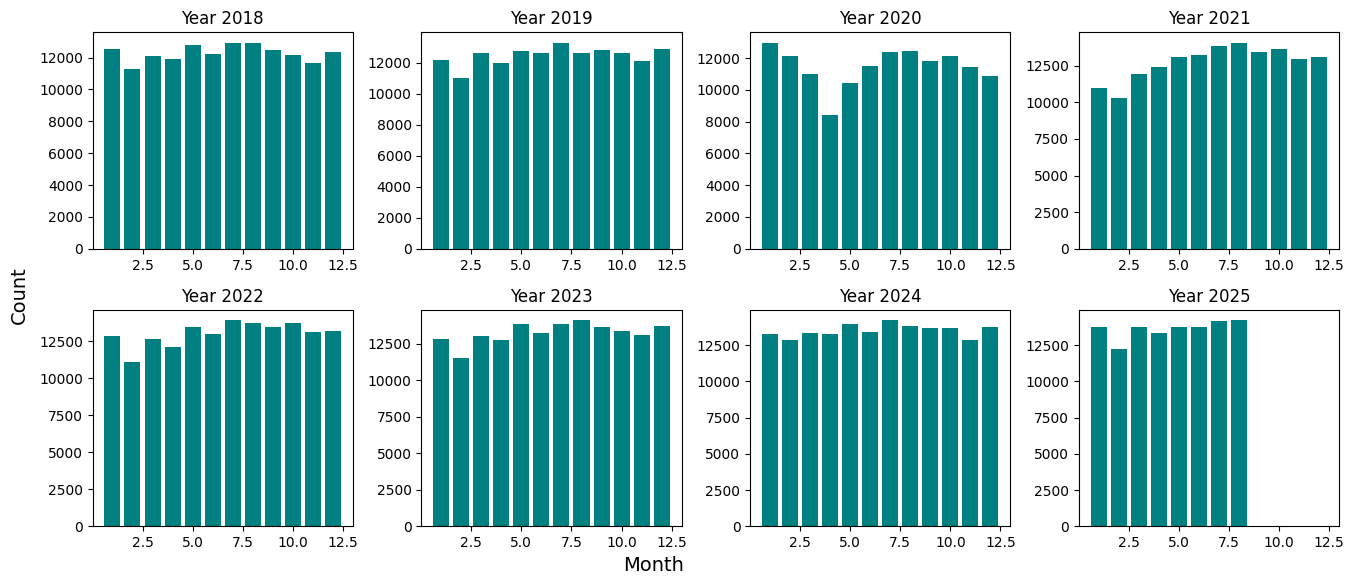

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(14,6))  
axes = axes.flatten() 

years = range(2018, 2026) 

for idx, j in enumerate(years):
    df_year = df[df['Date'].dt.year == j]
    test = df_year.groupby([df_year['Date'].dt.month, df_year['REASON_VISIT_NAME']]).size()

    count_of_reasons_per_month = [test.loc[i].sum() if i in test.index.levels[0] else 0 for i in range(1, 13)]

    axes[idx].bar(range(1, 13), count_of_reasons_per_month)
    axes[idx].set_title(f"Year {j}")
    # axes[idx].set_xlabel("Month")
    # axes[idx].set_ylabel("Count")

for ax in axes[len(years):]:
    fig.delaxes(ax)

fig.text(0.5, 0.04, 'Month', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Count', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()


,unique_entry_per_day,total_encounters,total_admittances,admitance_rate
Hour,,,,
0,33787,35636,8566,0.240375
1,27544,28936,7239,0.250173
2,23897,24997,6407,0.256311
3,20988,21860,5821,0.266285
4,19275,20052,5518,0.275185
5,19152,19918,5497,0.275982
6,22332,23300,6211,0.266567
7,28746,30209,7998,0.264756
8,40757,43750,11882,0.271589


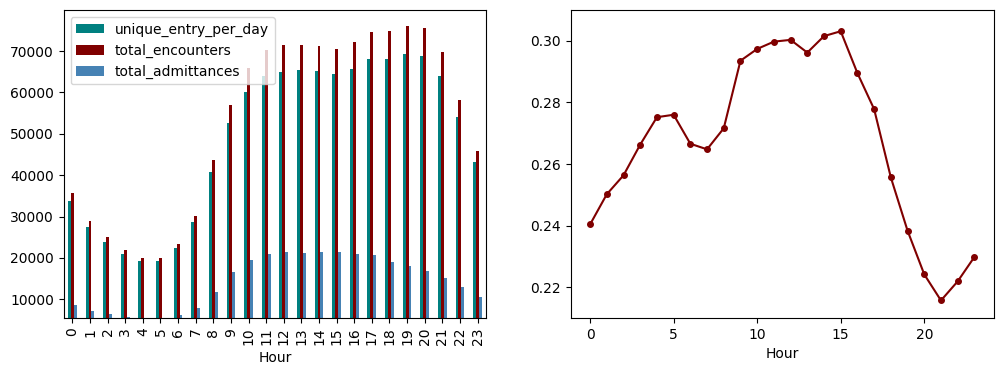

In [19]:
grouped_by_time = df.groupby(by = df['Hour']).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_time['admitance_rate'] = grouped_by_time['total_admittances'] / grouped_by_time['total_encounters']
display(grouped_by_time)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  
grouped_by_time.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_time.iloc[:,:-1].min()['total_admittances'], ax=axes[0])
grouped_by_time['admitance_rate'].plot(kind='line', ylim=(0.21,0.31), ax=axes[1], color='maroon', marker='o', markersize=4)
plt.show()


## Analysis by site

,site,total_encounters,total_admittances,admittance_rate
Site,,,,
A,308478,339622,107210,0.315674
B,423139,463877,118092,0.254576
C,250370,267847,81899,0.305768
D,192323,202365,35136,0.173627


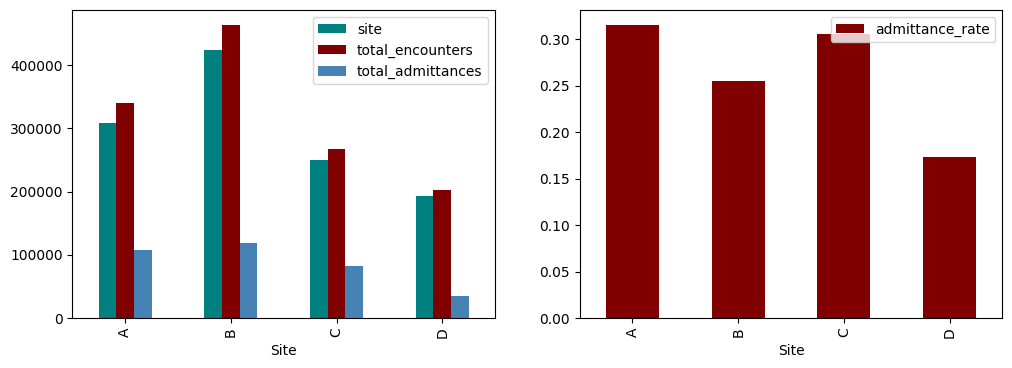

In [20]:
grouped_by_site = df.groupby(by='Site').agg(
    site = ('Site', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_site['admittance_rate'] = grouped_by_site['total_admittances'] /grouped_by_site['total_encounters']
display(grouped_by_site)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
grouped_by_site.iloc[:,:-1].plot(kind='bar', ax=axes[0]) # finally some sort of imbalance
grouped_by_site['admittance_rate'].plot(kind='bar', ax=axes[1], legend=True, color='maroon')
plt.show()

# Ways to move forward ? 

* Important: Decide on a forecasting model and start building it. Ideas: RNNs, Transformers, XGBoost, CatBoost (Gradient Boosting)

* Create a baseline.

* Divide and Conquer ? or should we all tackle the same part of the problem ? Come back to that after a baseline is set.

* Try different embedding models (BERT???????)

* Should we trust the clusters and do analytics using them ?

* Include models that are weighted using the rate_of_admission [DONE]

* Make a joint weight, out of the count of each REASON and the rate_of_admission [DONE]

In [21]:
df = pd.read_csv('insterted_clusters.csv', parse_dates=['Date'])
df

,Unnamed: 0,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted,kmeans | tf-idf,kmeans | tf-idf | raw_count,kmeans | tf-idf | log_count,...,bkmeans | tf-idf,bkmeans | tf-idf | raw_count,bkmeans | tf-idf | log_count,bkmeans | tf-idf | admission_rate,bkmeans | tf-idf | joint,bkmeans | bwv,bkmeans | bwv | raw_count,bkmeans | bwv | log_count,bkmeans | bwv | admission_rate,bkmeans | bwv | joint
0,0,A,2018-01-01,0,BREATHING PROBLEM,1,1,2,2,3,...,2,2,1,2,17,9,5,5,11,4
1,1,A,2018-01-01,0,BURN,1,0,2,6,4,...,2,3,15,2,7,3,0,13,17,1
2,2,A,2018-01-01,0,SHAKING,1,1,2,6,4,...,2,3,10,2,7,13,8,4,4,9
3,3,A,2018-01-01,0,VOMITING,1,0,2,14,4,...,2,3,10,2,12,14,10,10,3,17
4,4,A,2018-01-01,1,FROSTBITE,1,0,2,6,4,...,2,3,10,2,7,3,0,13,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1174305,1174305,D,2025-08-31,22,KNEE INJURY,1,0,2,10,2,...,2,5,6,2,12,3,0,13,17,0
1174306,1174306,D,2025-08-31,23,CHEST PAIN,1,0,3,4,1,...,2,3,23,2,3,15,15,8,1,2
1174307,1174307,D,2025-08-31,23,DIZZINESS,1,0,2,1,4,...,2,3,10,2,7,14,14,9,3,17
1174308,1174308,D,2025-08-31,23,FINGER PAIN,1,0,3,6,1,...,2,3,23,2,3,15,13,8,1,2


In [22]:
grouped_by_cluster_df = df.groupby(by='bkmeans | bwv | admission_rate').agg(
    total_enc=('ED Enc', 'sum'),
    total_adm=('ED Enc Admitted', 'sum')
)
grouped_by_cluster_df['admission_rate'] = grouped_by_cluster_df['total_adm'] / grouped_by_cluster_df['total_enc']

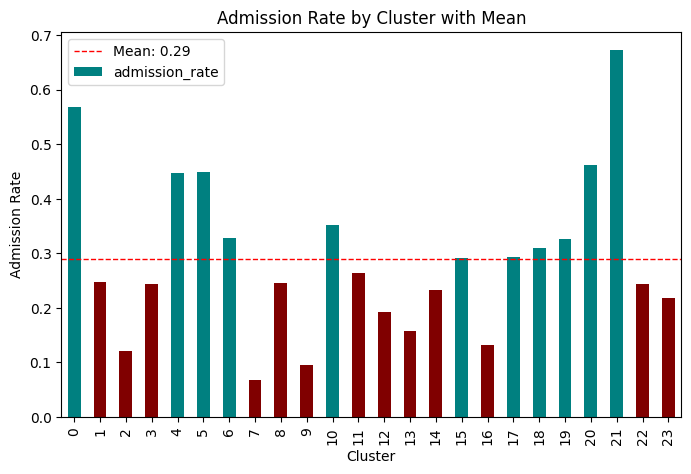

In [23]:
mean_value = grouped_by_cluster_df['admission_rate'].mean()
colors = ['teal' if x >= mean_value else 'maroon' for x in grouped_by_cluster_df['admission_rate']]
ax = grouped_by_cluster_df['admission_rate'].plot(kind='bar', color=colors, figsize=(8,5))
plt.axhline(mean_value, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean_value:.2f}')

plt.xlabel('Cluster')
plt.ylabel('Admission Rate')
plt.title('Admission Rate by Cluster with Mean')
plt.legend()

plt.show()

# Perhaps partition the clusters by importance given some threshold for each category.

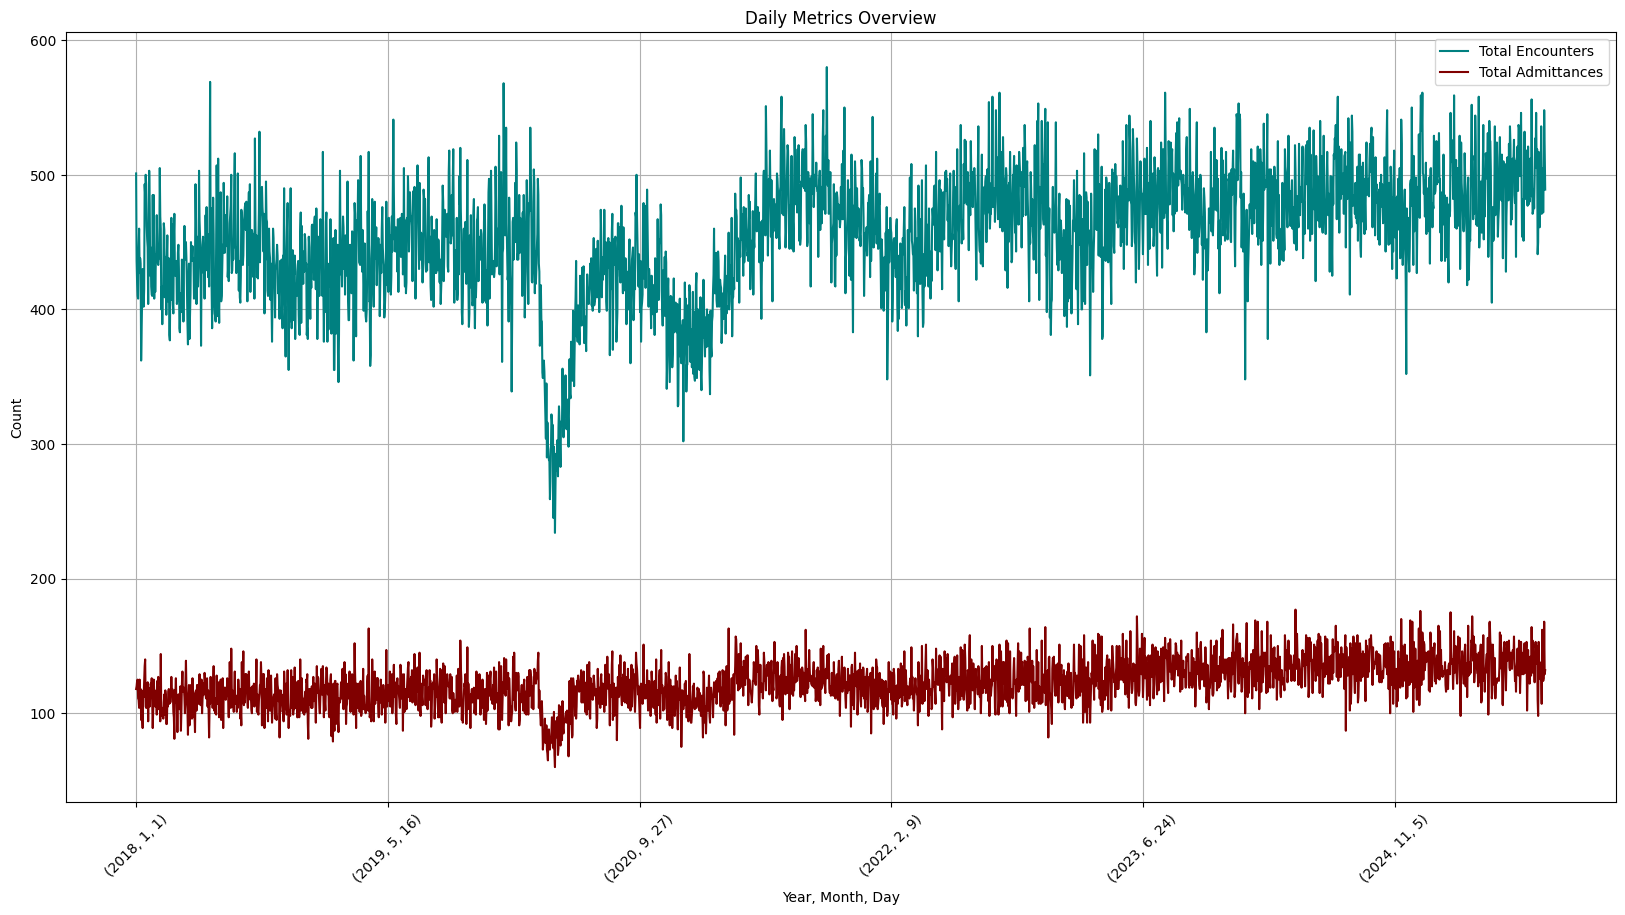

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

grouped_by_year_month_day = df.groupby(
    [df['Date'].dt.year, df['Date'].dt.month, df['Date'].dt.day]
).agg(
    unique_entry_per_day=('Date', 'size'),
    total_encounters=('ED Enc', 'sum'),
    total_admittances=('ED Enc Admitted', 'sum')
)

fig, ax = plt.subplots(figsize=(20,10))

grouped_by_year_month_day['total_encounters'].plot(
    kind='line', ax=ax, markersize=4, label='Total Encounters'
)
grouped_by_year_month_day['total_admittances'].plot(
    kind='line', ax=ax, markersize=4, label='Total Admittances'
)

ax.set_xlabel('Year, Month, Day')
ax.set_ylabel('Count')
ax.set_title('Daily Metrics Overview')
ax.legend()
ax.grid(True)

plt.xticks(rotation=45)

plt.show()


## TSA

[TSA and forecasting](https://www.geeksforgeeks.org/machine-learning/time-series-analysis-and-forecasting/)

#### Components of Time Series Data
- **Trend**: Long-term movement of data showing increase, decrease or stability can be linear or nonlinear.
- **Seasonality**: Regular patterns repeating at fixed intervals like daily, monthly or yearly, often due to seasons or events.
- **Cyclical Variations**: Long-term fluctuations without fixed periods, linked to economic or business cycles.
- **Irregularity (Noise)**: Random, unpredictable variations caused by events, errors or other unforeseen factors.

To make a "perfect" model, the model must capture the first three components, and the remaining series should be white noise.

### Year / Month

In [25]:
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm


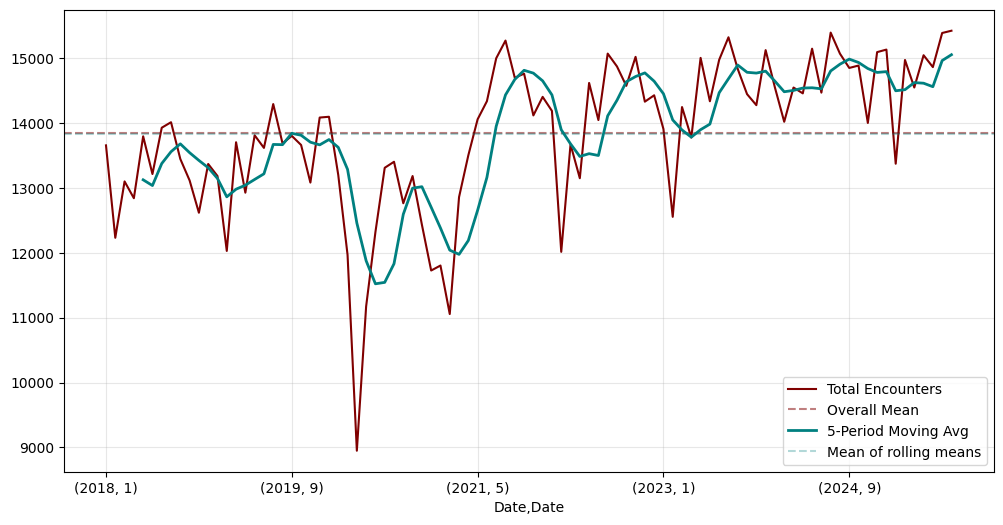

In [26]:
WINDOW = 5
plt.figure(figsize=(12, 6))

grouped_by_year_month['total_encounters'].plot(
    kind='line',
    color='maroon',
    label='Total Encounters'
)

plt.axhline(
    grouped_by_year_month['total_encounters'].mean(),
    linestyle='--',
    color='maroon',
    alpha=0.5,
    label='Overall Mean'
)

grouped_by_year_month['total_encounters'].rolling(window=WINDOW).mean().plot(
    label=f'{WINDOW}-Period Moving Avg',
    linewidth=2
)

plt.axhline(
    grouped_by_year_month['total_encounters'].rolling(window=WINDOW).mean().mean(),
    linestyle='--',
    color='teal',
    alpha=0.3,
    label='Mean of rolling means'
)

plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()


Perhaps redundant

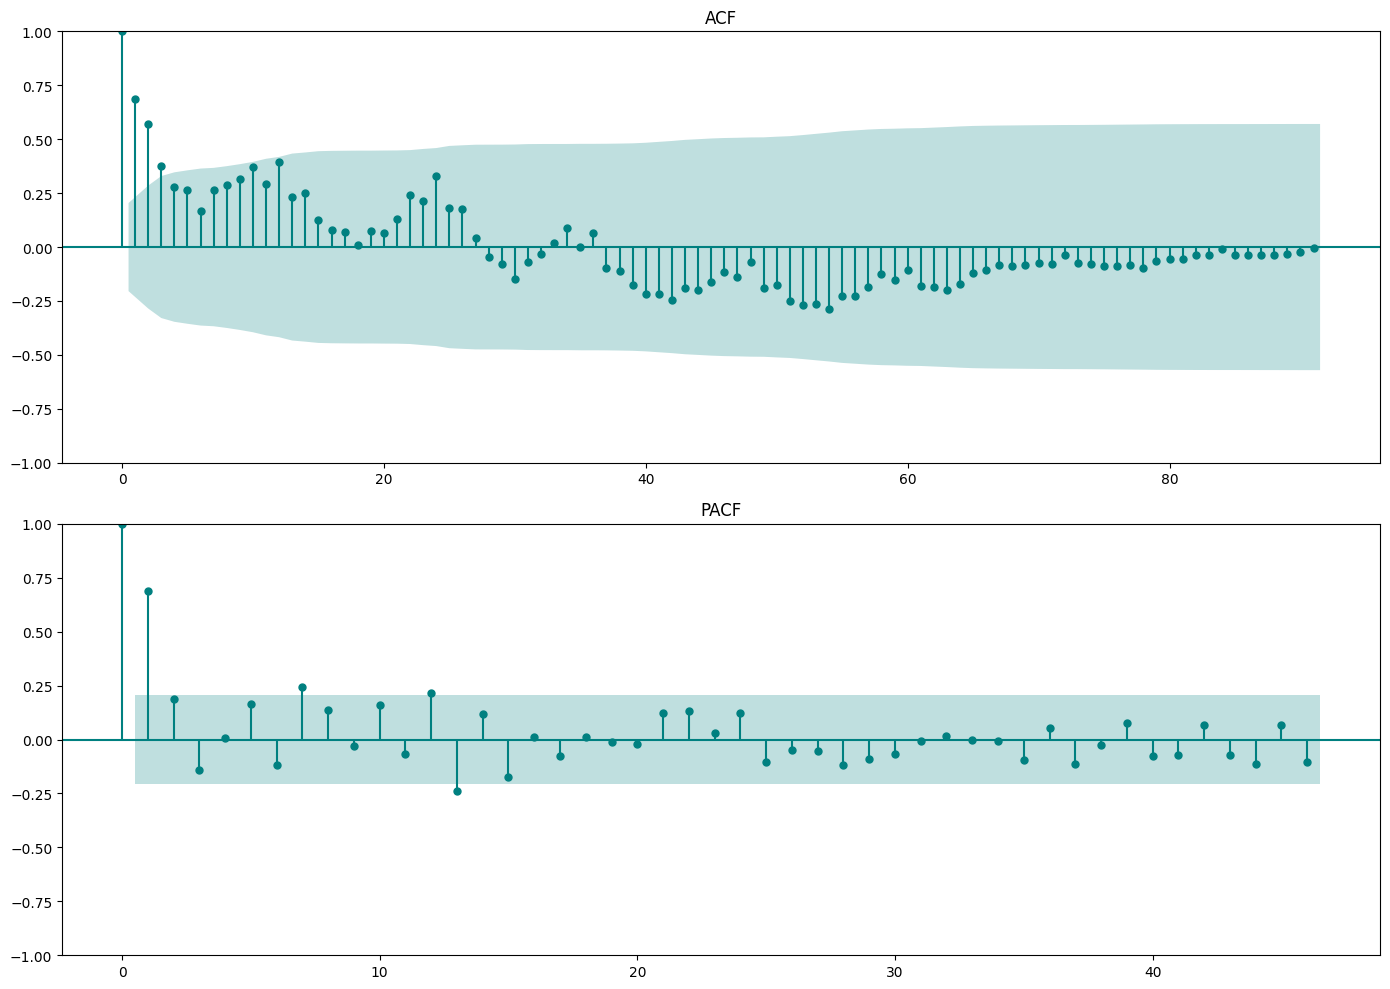

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(grouped_by_year_month['total_encounters'], ax=ax[0], lags=grouped_by_year_month.shape[0]-1)
ax[0].set_title("ACF")

plot_pacf(grouped_by_year_month['total_encounters'], ax=ax[1], lags=grouped_by_year_month.shape[0]/2)
ax[1].set_title("PACF")
plt.tight_layout()
plt.show()

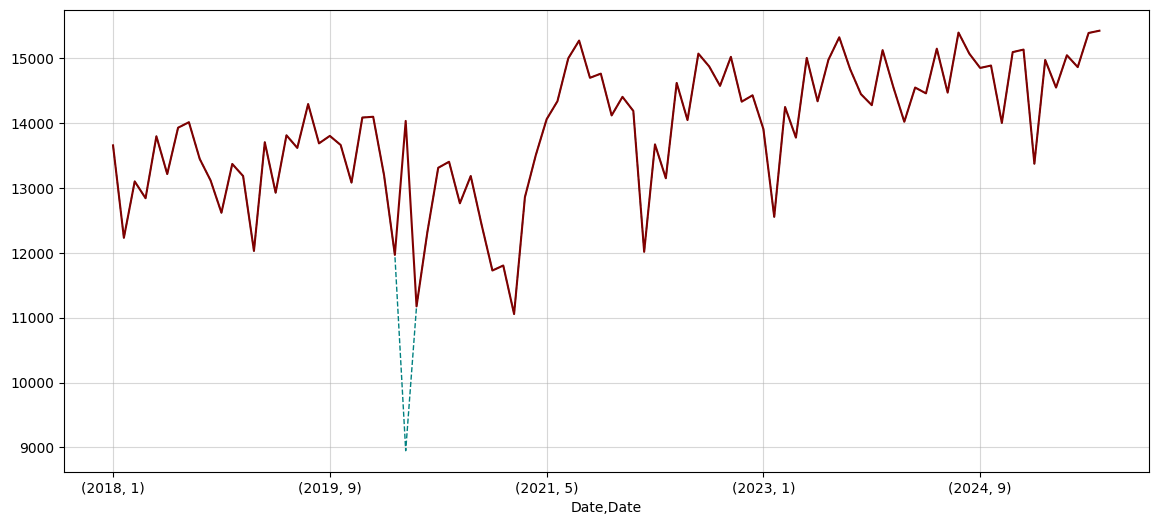

In [28]:
values = grouped_by_year_month['total_encounters']

z = np.abs((values - values.mean()) / values.std())
grouped_by_year_month["value_clean"] = np.where(z > 3, values.median(), values)
grouped_by_year_month['z']=z
plt.figure(figsize=(14,6))

grouped_by_year_month['total_encounters'].plot(kind='line', linestyle='--', alpha=1, linewidth=1)
grouped_by_year_month['value_clean'].plot(kind='line')
# grouped_by_year_month['z'].plot(kind='bar')

plt.grid(alpha=0.5)
plt.show()



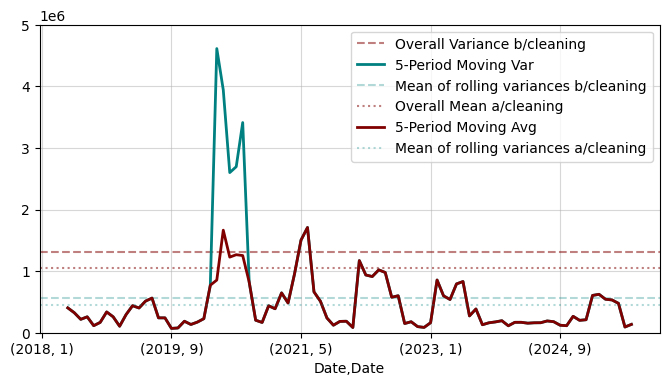

In [29]:
plt.figure(figsize=(8, 4))


plt.axhline(
    grouped_by_year_month['total_encounters'].var(),
    linestyle='--',
    color='maroon',
    alpha=0.5,
    label='Overall Variance b/cleaning'
)
grouped_by_year_month['total_encounters'].rolling(window=WINDOW).var().plot(
    label=f'{WINDOW}-Period Moving Var',
    linewidth=2,
)

plt.axhline(
    grouped_by_year_month['total_encounters'].rolling(window=WINDOW).var().mean(),
    linestyle='--',
    color='teal',
    alpha=0.3,
    label='Mean of rolling variances b/cleaning',
)



plt.axhline(
    grouped_by_year_month['value_clean'].var(),
    linestyle=':',
    color='maroon',
    alpha=0.5,
    label='Overall Mean a/cleaning'
)
grouped_by_year_month['value_clean'].rolling(window=WINDOW).var().plot(
    label=f'{WINDOW}-Period Moving Avg',
    linewidth=2
)

plt.axhline(
    grouped_by_year_month['value_clean'].rolling(window=WINDOW).var().mean(),
    linestyle=':',
    color='teal',
    alpha=0.3,
    label='Mean of rolling variances a/cleaning'
)

plt.legend()
plt.grid(alpha=0.5)
plt.ylim(0, 5e6)


plt.show()

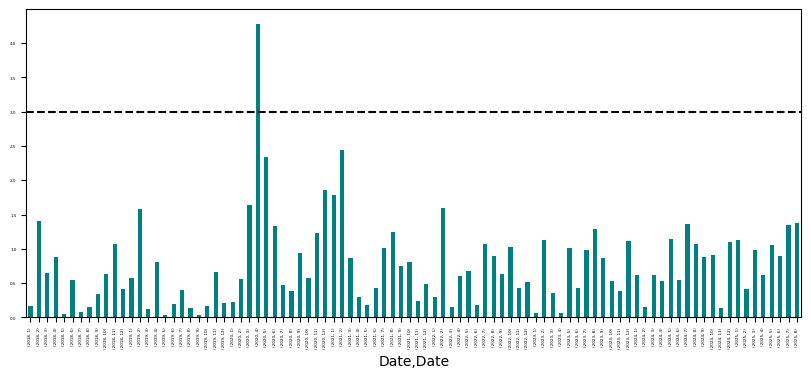

In [30]:
grouped_by_year_month.z.plot(kind='bar', figsize=(10,4), fontsize=3)
grouped_by_year_month.z.mean()
plt.axhline(3, linestyle='--', color='black')
plt.show()

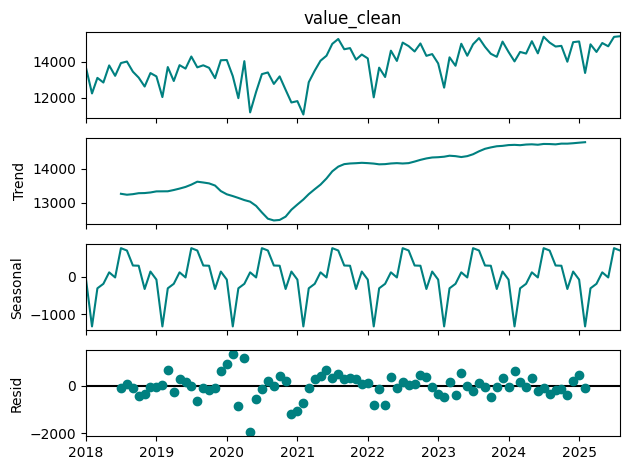

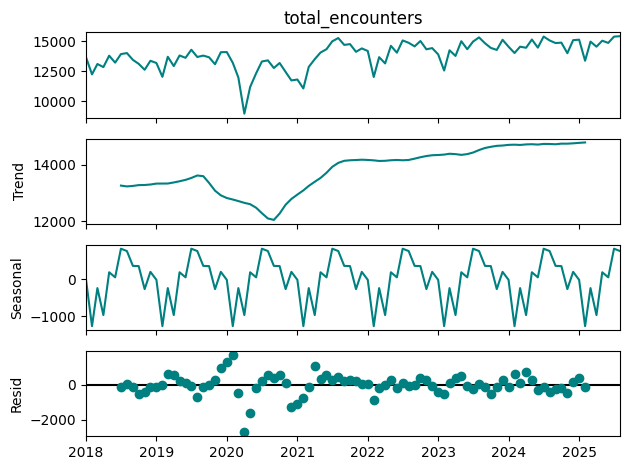

,lb_stat,lb_pvalue
10,27.560754,0.002122


In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Convert MultiIndex to datetime
# grouped_by_year_month = grouped_by_year_month.copy()  # avoid modifying original
# grouped_by_year_month['date'] = pd.to_datetime(
#     grouped_by_year_month.index.map(lambda x: f"{x[0]}-{x[1]}-01")
# )
# grouped_by_year_month = grouped_by_year_month.set_index('date')

# Now run seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomp1 = seasonal_decompose(grouped_by_year_month['value_clean'], model="additive", period=12)
decomp2 = seasonal_decompose(grouped_by_year_month['total_encounters'], model="additive", period=12)
decomp1.plot()
decomp2.plot()
plt.show()


from statsmodels.stats.diagnostic import acorr_ljungbox

# lbvalue = test statistic, pvalue = probability of observing the data if it's white noise
lbvalue, pvalue = acorr_ljungbox(decomp1.resid.dropna(), lags=[10], return_df=False)

acorr_ljungbox(decomp1.resid.dropna(), lags=[10], return_df=False)






In [34]:
train_size = int(len(grouped_by_year_month) * 0.8)  
train = grouped_by_year_month['total_encounters'].dropna()[:train_size]
test = grouped_by_year_month['total_encounters'].dropna()[train_size:]

In [35]:
import pmdarima as pm
model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1183.625, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1191.419, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1183.980, Time=0.02 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1185.449, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1189.432, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=1184.487, Time=0.23 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=0.76 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=1185.690, Time=0.25 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   73
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -585.561
Date:                            Mon, 19 Jan 2026   AIC                           1179.121
Time:                                    13:48:36   BIC                           1188.228
Sample:                                01-01-2018   HQIC                          1182.747
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1561      0.077     -2.028      0.043      -0.307      -0.005
ar.S.L12       0.8830      0.220      4.014      0.000       0.452       1.314
ma.S.L12      -0.7374      0.302     -2.444      0.015      -1.329      -0.146
sigma2      6.078e+05   9.64e+04      6.307      0.000    4.19e+05    7.97e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                12.41
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               1.05   Skew:                            -0.56
Prob(H) (two-sided):                  0.91   Kurtosis:                         4.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

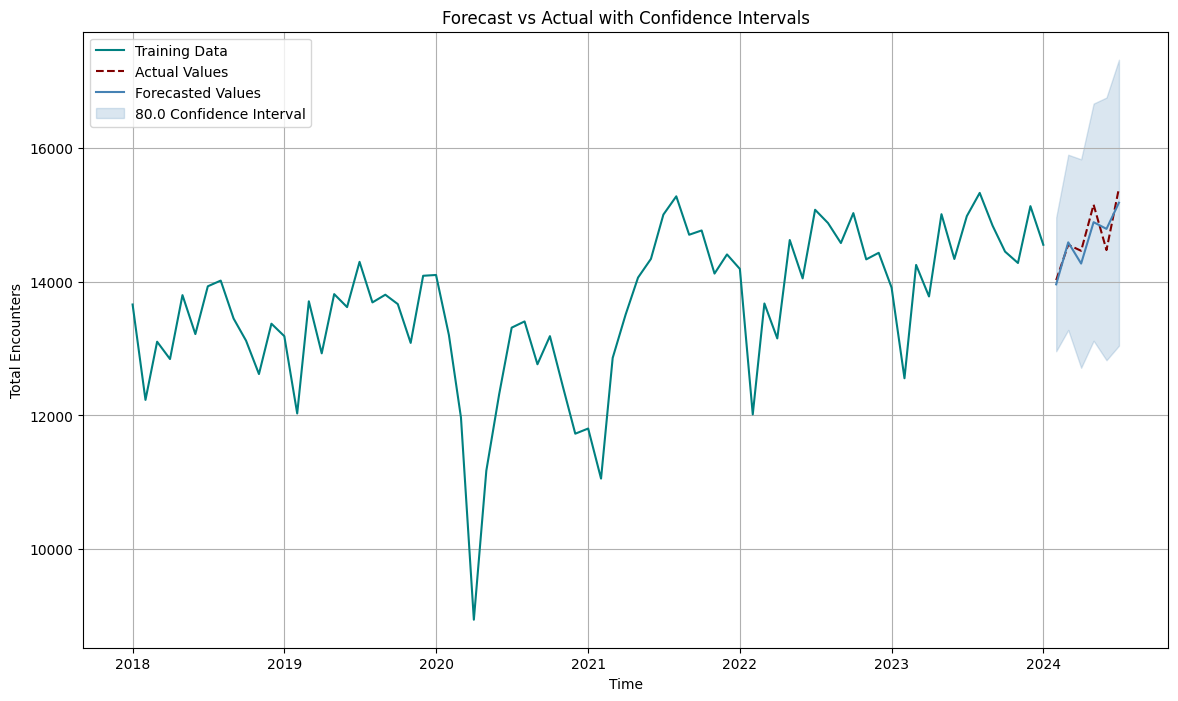

In [44]:
n_periods=6
alpha = 0.2
forecast_result = model.predict(n_periods=n_periods, return_conf_int=True, alpha=alpha)
forecast_values, conf_int = forecast_result

forecast = pd.Series(forecast_values, index=test.index)
conf_int_df = pd.DataFrame(conf_int, index=test.index[:n_periods], columns=['lower', 'upper'])

plt.figure(figsize=(14,8))
plt.plot(train, label='Training Data')
plt.plot(test[:n_periods], label='Actual Values', linestyle='--')
plt.plot(forecast, label='Forecasted Values')

plt.fill_between(conf_int_df.index,
                 conf_int_df['lower'],
                 conf_int_df['upper'],
                 color='steelblue', alpha=0.2, label=f'{(1-alpha)*100} Confidence Interval')

plt.title("Forecast vs Actual with Confidence Intervals")
plt.xlabel("Time")
plt.ylabel("Total Encounters")
plt.legend()
plt.grid(True)
plt.show()


In [45]:
residuals = test - forecast
residuals

date
2024-02-01     62.743240
2024-03-01    -36.444597
2024-04-01    190.701868
2024-05-01    261.331200
2024-06-01   -316.491860
2024-07-01    218.491617
2024-08-01           NaN
2024-09-01           NaN
2024-10-01           NaN
2024-11-01           NaN
2024-12-01           NaN
2025-01-01           NaN
2025-02-01           NaN
2025-03-01           NaN
2025-04-01           NaN
2025-05-01           NaN
2025-06-01           NaN
2025-07-01           NaN
2025-08-01           NaN
dtype: float64

<Axes: xlabel='date'>

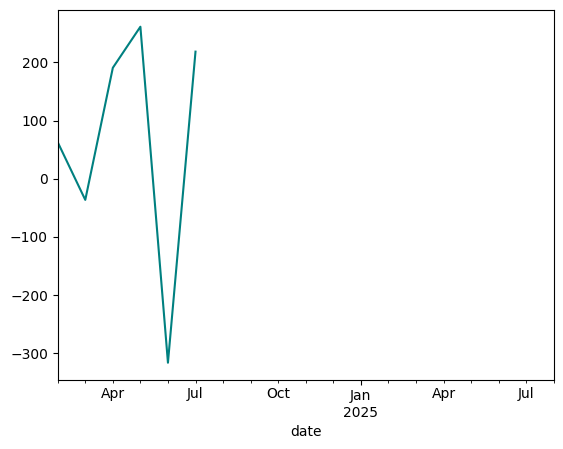

In [46]:
residuals.plot(kind='line')

In [47]:
residuals.mean()

np.float64(63.3885780604381)

In [48]:
# MSE
np.sqrt(np.mean(residuals**2))

np.float64(207.29681026529497)

In [49]:
# MAPE
round(np.mean(abs(residuals/test)),4)

np.float64(0.0122)

### Year / Month / Day

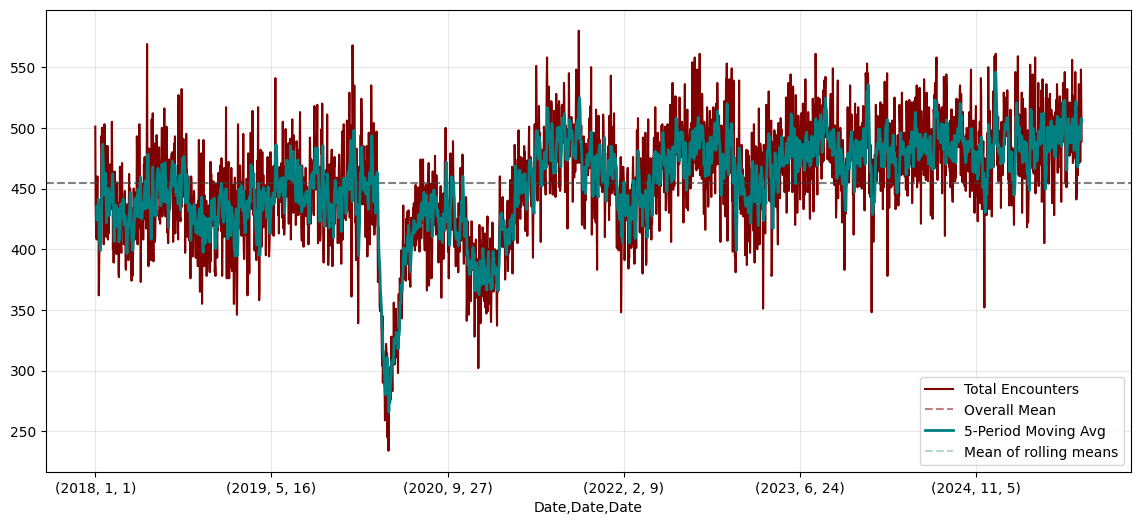

In [ ]:
WINDOW = 5
plt.figure(figsize=(14, 6))

grouped_by_year_month_day['total_encounters'].plot(
    kind='line',
    color='maroon',
    label='Total Encounters'
)

plt.axhline(
    grouped_by_year_month_day['total_encounters'].mean(),
    linestyle='--',
    color='maroon',
    alpha=0.5,
    label='Overall Mean'
)

grouped_by_year_month_day['total_encounters'].rolling(window=WINDOW).mean().plot(
    label=f'{WINDOW}-Period Moving Avg',
    linewidth=2
)

plt.axhline(
    grouped_by_year_month_day['total_encounters'].rolling(window=WINDOW).mean().mean(),
    linestyle='--',
    color='teal',
    alpha=0.3,
    label='Mean of rolling means'
)

plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()


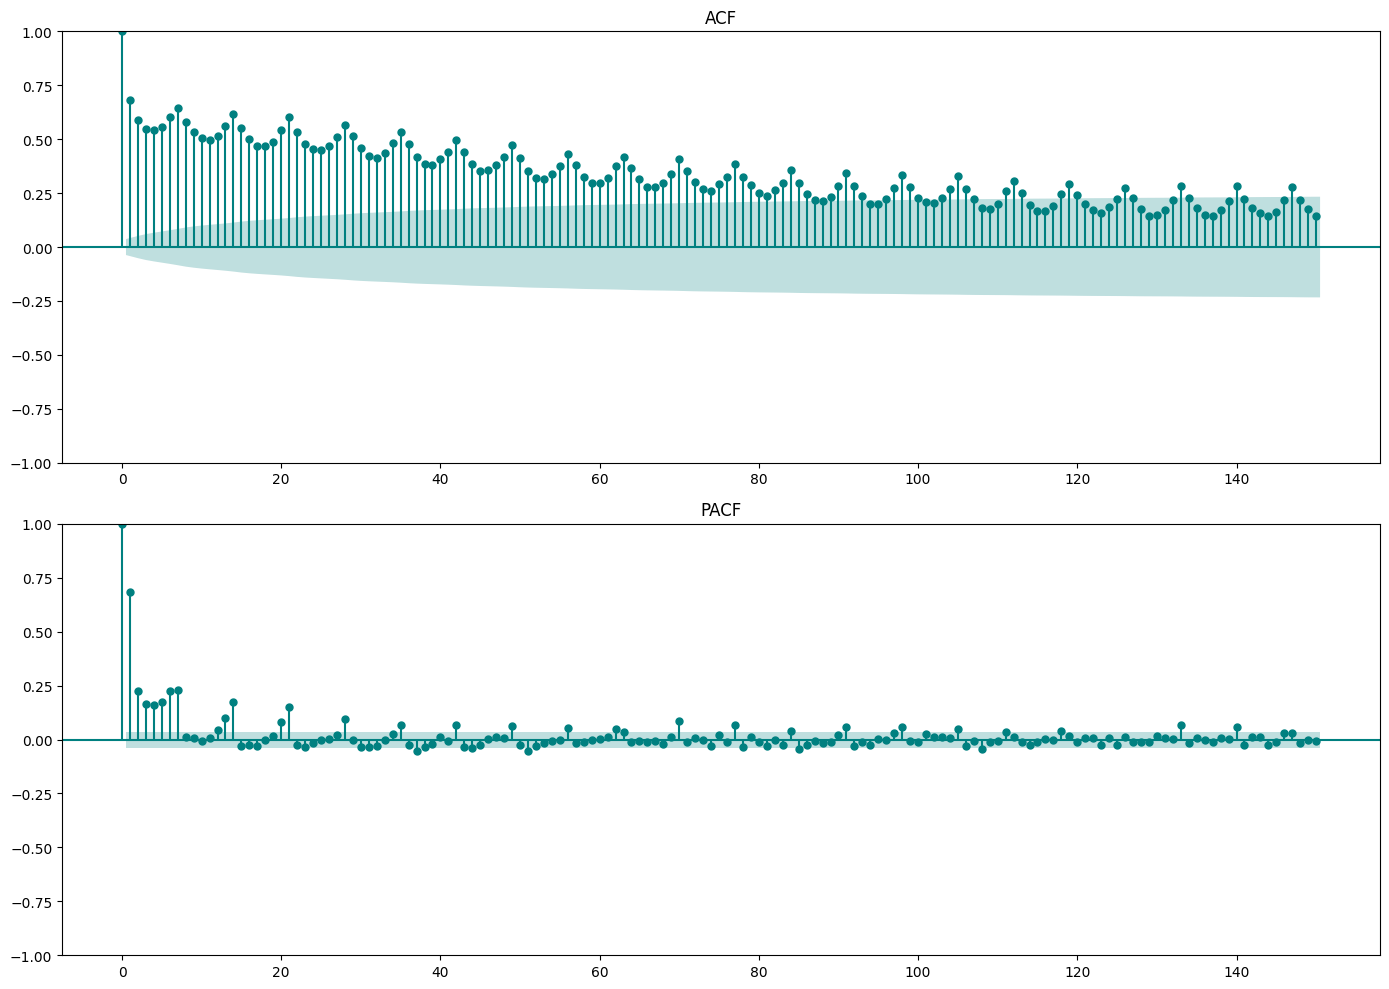

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(grouped_by_year_month_day['total_encounters'], ax=ax[0], lags=150)
ax[0].set_title("ACF")

plot_pacf(grouped_by_year_month_day['total_encounters'], ax=ax[1], lags=150)
ax[1].set_title("PACF")
plt.tight_layout()
plt.show()

In [ ]:
grouped_by_year_month_day

unique_entry_per_day  total_encounters  total_admittances
Date Date Date                                                           
2018 1    1                      455               501                118
          2                      411               436                120
          3                      394               420                124
          4                      368               410                125
          5                      375               408                111
...                              ...               ...                ...
2025 8    27                     441               472                124
          28                     459               498                126
          29                     509               548                168
          30                     480               518                129
          31                     453               489                132

[2800 rows x 3 columns]

In [ ]:
# Convert MultiIndex to datetime
grouped_by_year_month_day['date'] = pd.to_datetime(
    grouped_by_year_month_day.index.map(lambda x: f"{x[0]}-{x[1]}-{x[2]}")
)
grouped_by_year_month_day = grouped_by_year_month_day.set_index('date')

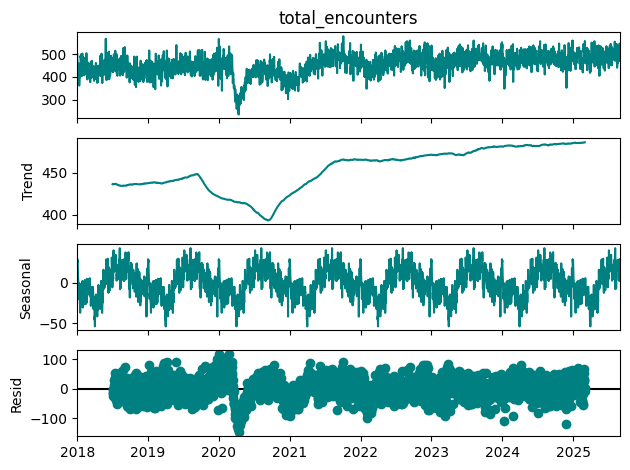

,lb_stat,lb_pvalue
10,3111.889936,0.0


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose



# Now run seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomp = seasonal_decompose(grouped_by_year_month_day['total_encounters'], model="additive", period=365)
decomp.plot()
plt.show()


from statsmodels.stats.diagnostic import acorr_ljungbox

# lbvalue = test statistic, pvalue = probability of observing the data if it's white noise
lbvalue, pvalue = acorr_ljungbox(decomp.resid.dropna(), lags=[10], return_df=False)

acorr_ljungbox(decomp.resid.dropna(), lags=[10], return_df=False)






In [ ]:
train_size = int(len(grouped_by_year_month_day) * 0.8)  
train = grouped_by_year_month_day['total_encounters'].dropna()[:train_size]
test = grouped_by_year_month_day['total_encounters'].dropna()[train_size:]